In [100]:
import torch
import matplotlib.pyplot as plt

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.internal_coordinates import Coordinates_mapping

In [101]:
mlps = [load_pickle_file("models/is{:d}_mlp_dic_training.pkl".format(mode_label)) for mode_label in [0, 1]]

zmats_train = [torch.cat([load_csv_file("datasets/is{:d}_{:s}_train.csv".format(mode_label, kind)).T for kind in ['flow', 'md']], dim=1).T for mode_label in [0, 1]]

In [102]:
zmats_train[0]
coord_mapping = Coordinates_mapping()
xs_train, xs_logdetjacs = coord_mapping.get_real_centered_from_internal(zmats_train[0][:, :12], logdetjacs=zmats_train[0][:, 14], isomer=0)

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

In [103]:
u_target = zmats_train[0][:, 12].detach().numpy()
u_predict = mlps[0]['model'](xs_train).T.detach().numpy()
#u_predict = coord_mapping.compute_energy_in_new_frame(mlps[0]['model'](xs_train).T, logdetjac=xs_logdetjacs).detach().numpy()

In [104]:
u_predict.shape, u_target.shape, u_target.flatten()[:100].shape, u_predict.flatten()[:100].shape

((1, 6000), (6000,), (100,), (100,))

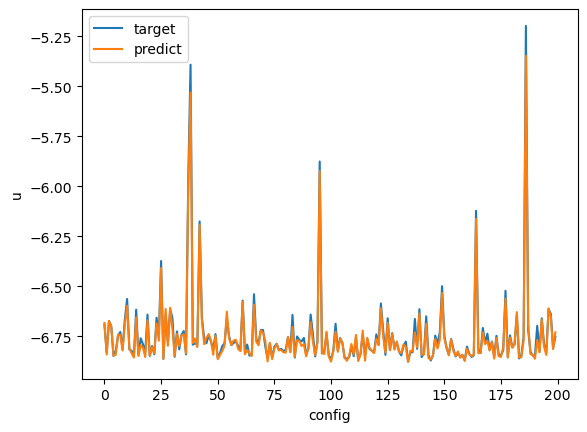

In [105]:
fig, ax = plt.subplots(1, 1)
ax.plot(u_target.flatten()[:200], label = 'target')
ax.plot(u_predict.flatten()[:200], label = 'predict')
ax.set_ylabel('u')
ax.set_xlabel('config')
ax.legend()

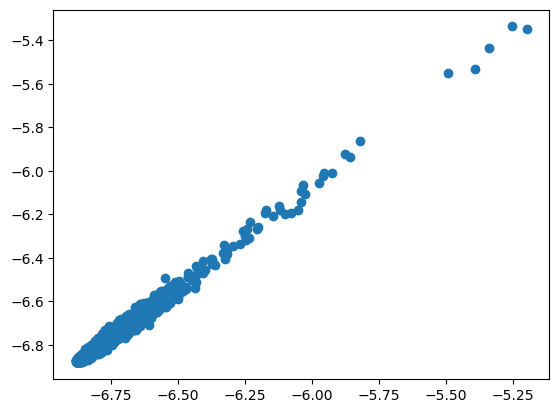

In [107]:
plt.scatter(u_target.flatten(), u_predict.flatten())